# ECG Arrhythmia Classification using Hybrid Autoencoder-CNN

---

## Biomedical Signal Processing Project

Master of Biomedical Engineering

---

### Paper

Hybrid Autoencoder-CNN Model for Accurate ECG Arrhythmia Classification Using the MIT-BIH Arrhythmia Database

Published in IEEE GCWCN 2025

---

**Prepared by**

Nazanin Sarabi

---

**Notebook Version**

v0.1.0

# About this Notebook

این Notebook برای بازتولید مرحله‌به‌مرحله مقاله انتخاب‌شده طراحی شده است.

برخلاف مقاله که تنها نتایج نهایی را ارائه می‌کند، در این Notebook تمام مراحل به‌صورت آموزشی توضیح داده می‌شوند تا علاوه بر پیاده‌سازی، دلیل انجام هر مرحله نیز مشخص باشد.

در پایان این پروژه انتظار می‌رود بتوانید:

- ساختار دیتاست MIT-BIH را توضیح دهید.
- مراحل آماده‌سازی سیگنال ECG را پیاده‌سازی کنید.
- معماری Hybrid Autoencoder-CNN را درک کنید.
- نتایج مقاله را بازتولید و تحلیل کنید.

# Roadmap

در طول پروژه، این Notebook به‌صورت مرحله‌به‌مرحله تکمیل خواهد شد.

مراحل اصلی عبارت‌اند از:

1. Dataset Introduction
2. Exploratory Data Analysis
3. Signal Preprocessing
4. Heartbeat Segmentation
5. Dataset Preparation
6. Autoencoder
7. CNN Classifier
8. Hybrid Autoencoder-CNN
9. Model Evaluation
10. Reproducing Paper Results

# 1. Dataset Introduction

در این بخش با دیتاست MIT-BIH Arrhythmia Database آشنا می‌شویم و اولین رکورد ECG را بارگذاری می‌کنیم.

هدف این مرحله تنها خواندن داده‌ها و آشنایی اولیه با ساختار فایل‌های WFDB است.

In [13]:
# Import required libraries

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb

WFDB is the official Python package for reading PhysioNet databases.

کتابخانه **WFDB** کتابخانه رسمی PhysioNet برای کار با دیتاست‌های سیگنال زیستی است.

MIT-BIH ECG signals are distributed in WFDB format (.hea, .dat, .atr).

در دیتاست MIT-BIH هر رکورد از سه فایل اصلی تشکیل شده است:

- فایل هدر (`.hea`)
- فایل سیگنال (`.dat`)
- فایل برچسب‌ها (`.atr`)

در این مرحله تنها فایل سیگنال را بارگذاری می‌کنیم و در مرحله بعد فایل برچسب‌ها را بررسی خواهیم کرد.

آدرس دانلود دیتاست
https://physionet.org/content/mitdb/ 



In [14]:
# Load one ECG record

DATA_DIR = Path("../data/raw")

record = wfdb.rdrecord(str(DATA_DIR / "100"))

record

# ECG Arrhythmia Classification using Hybrid Autoencoder-CNN

---

## Biomedical Signal Processing Project

Master of Biomedical Engineering

---

### Paper

Hybrid Autoencoder-CNN Model for Accurate ECG Arrhythmia Classification Using the MIT-BIH Arrhythmia Database

Published in IEEE GCWCN 2025

---

**Prepared by**

Nazanin Sarabi

---

**Notebook Version**

v0.1.0

# About this Notebook

این Notebook برای بازتولید مرحله‌به‌مرحله مقاله انتخاب‌شده طراحی شده است.

برخلاف مقاله که تنها نتایج نهایی را ارائه می‌کند، در این Notebook تمام مراحل به‌صورت آموزشی توضیح داده می‌شوند تا علاوه بر پیاده‌سازی، دلیل انجام هر مرحله نیز مشخص باشد.

در پایان این پروژه انتظار می‌رود بتوانید:

- ساختار دیتاست MIT-BIH را توضیح دهید.
- مراحل آماده‌سازی سیگنال ECG را پیاده‌سازی کنید.
- معماری Hybrid Autoencoder-CNN را درک کنید.
- نتایج مقاله را بازتولید و تحلیل کنید.

# Roadmap

در طول پروژه، این Notebook به‌صورت مرحله‌به‌مرحله تکمیل خواهد شد.

مراحل اصلی عبارت‌اند از:

1. Dataset Introduction
2. Exploratory Data Analysis
3. Signal Preprocessing
4. Heartbeat Segmentation
5. Dataset Preparation
6. Autoencoder
7. CNN Classifier
8. Hybrid Autoencoder-CNN
9. Model Evaluation
10. Reproducing Paper Results

In [15]:
# Import required libraries

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb

WFDB is the official Python package for reading PhysioNet databases.
کتابخانه **WFDB** کتابخانه رسمی PhysioNet برای کار با دیتاست‌های سیگنال زیستی است.

در دیتاست MIT-BIH هر رکورد از سه فایل اصلی تشکیل شده است:

- فایل هدر (`.hea`)
- فایل سیگنال (`.dat`)
- فایل برچسب‌ها (`.atr`)

در این مرحله تنها فایل سیگنال را بارگذاری می‌کنیم و در مرحله بعد فایل برچسب‌ها را بررسی خواهیم کرد.

https://physionet.org/content/mitdb/ 

Therefore, using the official library is the safest and most reliable approach.

In [19]:
# Load one ECG record

DATA_DIR = Path("../data/raw")

record = wfdb.rdrecord(str(DATA_DIR / "100"))

record

شیء بازگشتی شامل اطلاعات کامل رکورد است؛ از جمله:

- تعداد نمونه‌ها
- نرخ نمونه‌برداری
- نام لیدهای ECG
- داده‌های سیگنال

In [21]:
# Display record information

print(f"Signal shape     : {record.p_signal.shape}")
print(f"Sampling rate    : {record.fs} Hz")
print(f"Signal channels  : {record.sig_name}")

Signal shape     : (650000, 2)
Sampling rate    : 360 Hz
Signal channels  : ['MLII', 'V5']


### تحلیل

در این رکورد مشاهده می‌کنیم که:

- سیگنال دارای دو لید ECG است.
- نرخ نمونه‌برداری برابر با **360 هرتز** است.
- هر سطر از ماتریس سیگنال متناظر با یک نمونه زمانی است.

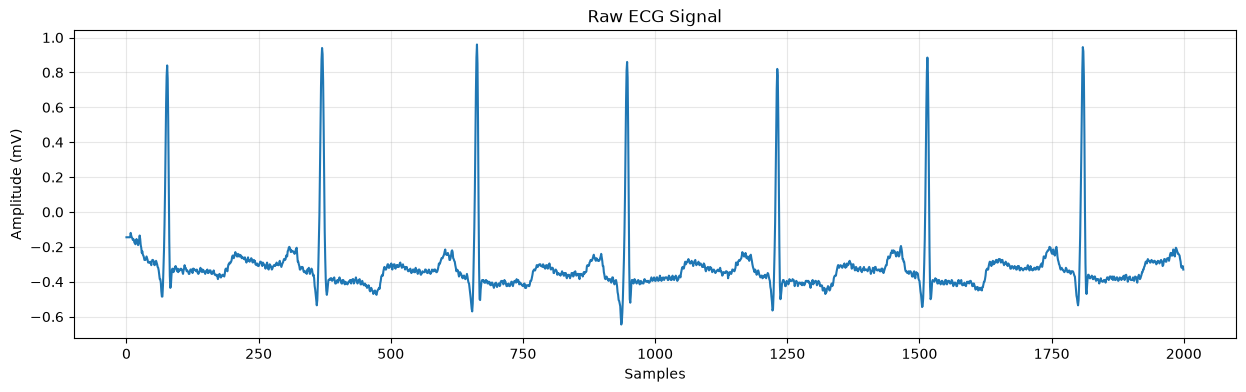

In [23]:
# Plot the raw ECG signal

plt.figure(figsize=(15, 4))
plt.plot(record.p_signal[:2000, 0])
plt.title("Raw ECG Signal")

plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")
plt.grid(alpha=0.3)

plt.show()

## What do we observe?

در نمودار بالا، سیگنال خام ECG مربوط به لید اول نمایش داده شده است.

با مشاهده شکل موج می‌توان چرخه‌های تکرارشونده ضربان قلب را تشخیص داد.

قله‌های بلند موجود در سیگنال، همان **R-Peak**ها هستند که مهم‌ترین نقاط هر ضربان قلب محسوب می‌شوند.

در مرحله بعد، این نقاط را با استفاده از فایل برچسب‌های دیتاست بررسی خواهیم کرد.

---

# 2. Exploratory Data Analysis

قبل از ساخت هر مدل یادگیری ماشین، لازم است ساختار داده و برچسب‌های آن را بررسی کنیم.

در این بخش با فایل Annotation آشنا می‌شویم و محل ضربان‌های قلب را روی سیگنال مشاهده خواهیم کرد.

---

## Learning Objectives

پس از پایان این بخش خواهید توانست:

- فایل Annotation را بخوانید.
- ساختار فایل atr را توضیح دهید.
- محل R-Peakها را استخراج کنید.
- توزیع کلاس‌های ضربان قلب را تحلیل کنید.
- ارتباط بین سیگنال و برچسب‌ها را درک کنید.

In [24]:
# Load annotation file

annotation = wfdb.rdann(str(DATA_DIR / "100"), "atr")

annotation

فایل Annotation شامل اطلاعاتی است که توسط متخصصان قلب ثبت شده‌اند.

هر Annotation حداقل دو بخش مهم دارد:

- شماره نمونه‌ای که ضربان در آن رخ داده است.
- نوع ضربان قلب.

در مراحل بعد، همین اطلاعات برای استخراج ضربان‌های قلب و ساخت مجموعه داده آموزشی استفاده خواهند شد.

In [25]:
# Display basic annotation information

print(f"Number of annotations : {len(annotation.sample)}")

print()

print("First 10 sample indices")

print(annotation.sample[:10])

print()

print("First 10 beat symbols")

print(annotation.symbol[:10])

Number of annotations : 2274

First 10 sample indices
[  18   77  370  662  946 1231 1515 1809 2044 2402]

First 10 beat symbols
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


### تحلیل خروجی

در خروجی بالا دو ویژگی مهم مشاهده می‌شود.

فهرست اول، شماره نمونه‌هایی را نشان می‌دهد که در آن‌ها یک رویداد ثبت شده است.

فهرست دوم، نوع هر رویداد را مشخص می‌کند.

البته تمام Annotationها مربوط به ضربان قلب نیستند؛ برخی از آن‌ها تنها رویدادهای کمکی دیتاست هستند.

در مراحل بعد، فقط ضربان‌های موردنیاز مقاله را انتخاب خواهیم کرد.

In [27]:
# Create annotation table

annotation_df = pd.DataFrame(
    {
        "sample": annotation.sample,
        "symbol": annotation.symbol,
    }
)

annotation_df.head(15)

,sample,symbol
0,18,+
1,77,N
2,370,N
3,662,N
4,946,N
5,1231,N
6,1515,N
7,1809,N
8,2044,A
9,2402,N


استفاده از یک DataFrame باعث می‌شود تحلیل داده بسیار ساده‌تر شود.

از این مرحله به بعد، بسیاری از تحلیل‌های آماری و ترسیم نمودارها بر اساس همین جدول انجام خواهند شد.

در پروژه‌های واقعی نیز معمولاً Annotationها ابتدا به یک ساختار جدولی تبدیل می‌شوند.

In [28]:
# Count annotation symbols

annotation_df["symbol"].value_counts()

symbol
N    2239
A      33
+       1
V       1
Name: count, dtype: int64

### تحلیل خروجی

در این جدول مشاهده می‌کنید که تمام نمادها تعداد یکسانی ندارند.

این موضوع نشان می‌دهد که توزیع داده‌ها نامتوازن است.

در مسائل طبقه‌بندی ECG، این یکی از مهم‌ترین چالش‌ها محسوب می‌شود؛ زیرا اگر مدل بدون درنظر گرفتن این عدم توازن آموزش ببیند، معمولاً عملکرد بهتری روی کلاس‌های پرتکرار خواهد داشت و کلاس‌های نادر را با دقت کمتری تشخیص می‌دهد.

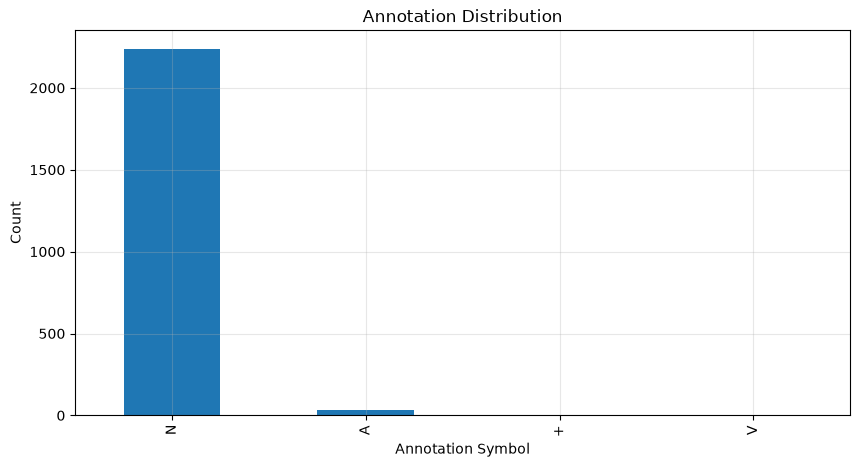

In [29]:
# Plot annotation distribution

plt.figure(figsize=(10,5))

annotation_df["symbol"].value_counts().plot(kind="bar")

plt.title("Annotation Distribution")

plt.xlabel("Annotation Symbol")

plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

این نمودار نمای کلی از توزیع برچسب‌های دیتاست را نشان می‌دهد.

در این مرحله تنها هدف ما شناخت ساختار داده است.

در مراحل بعد، پس از انتخاب کلاس‌های موردنیاز مقاله، توزیع کلاس‌ها دوباره بررسی خواهد شد.

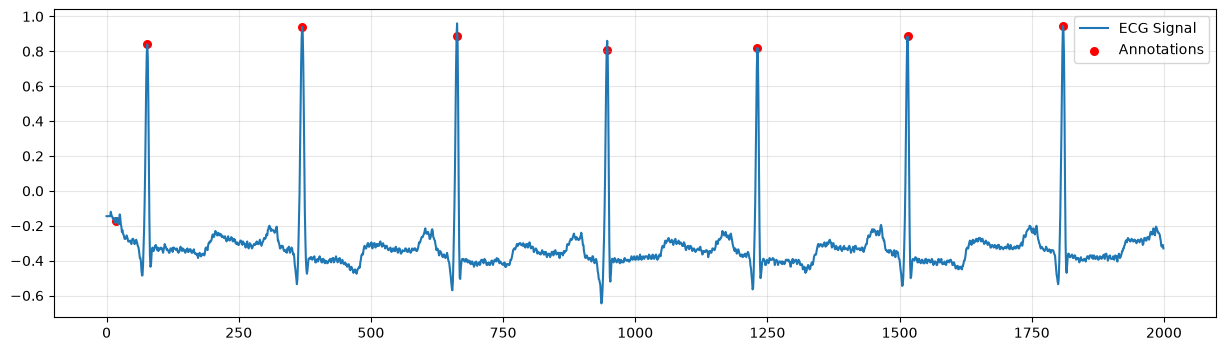

In [31]:
# Show ECG signal with annotations

signal = record.p_signal[:, 0]

start = 0
end = 2000

plt.figure(figsize=(15,4))

plt.plot(signal[start:end], label="ECG Signal")

selected_samples = annotation.sample[
    (annotation.sample >= start) &
    (annotation.sample <= end)
]

plt.scatter(
    selected_samples,
    signal[selected_samples],
    color="red",
    s=30,
    label="Annotations"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

در این شکل، نقاط قرمز محل رویدادهای ثبت‌شده در فایل Annotation را نشان می‌دهند.

این برچسب‌ها مرجع اصلی (Ground Truth) دیتاست هستند و تمام مراحل آموزش و ارزیابی مدل بر پایه آن‌ها انجام خواهد شد.

در مرحله بعد، یاد می‌گیریم چگونه فقط ضربان‌های موردنیاز مقاله را از میان این Annotationها انتخاب کنیم.

## Key Takeaways

در پایان این بخش، با مهم‌ترین اجزای فایل Annotation آشنا شدید.

اکنون می‌دانید که:

- فایل Annotation محل وقوع رویدادها را مشخص می‌کند.
- هر Annotation دارای یک شماره نمونه و یک نماد است.
- توزیع برچسب‌ها نامتوازن است.
- این برچسب‌ها مبنای استخراج ضربان‌های قلب در مراحل بعد خواهند بود.

در مرحله بعد، وارد بخش آماده‌سازی سیگنال و استخراج ضربان‌های قلب خواهیم شد.

SyntaxError: invalid character '،' (U+060C) (2821831514.py, line 3)